In [1]:
!pip install datasets pandas matplotlib seaborn scikit-learn nltk

In [2]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("surrey-nlp/BESSTIE-CW-26")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})


In [3]:
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

df = pd.concat([train_df, val_df, test_df])

df.head()

,text,variety,source,Sentiment,Sarcasm
0,I'm a member of the Green Party but I'll be vo...,en-UK,Reddit,0.0,0.0
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0
2,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0
3,Firstly the staff seemed as if they did n't wa...,en-UK,Google,0.0,0.0
4,We came for lunch and enjoyed the food we orde...,en-UK,Google,1.0,0.0


In [4]:
print("Dataset shape:", df.shape)
print(df.columns)

df['variety'].value_counts()

Dataset shape: (6243, 5)
Index(['text', 'variety', 'source', 'Sentiment', 'Sarcasm'], dtype='object')


,count
variety,
en-IN,2332
en-UK,2004
en-AU,1907


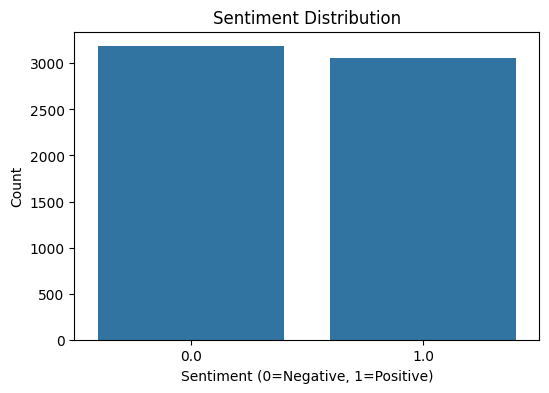

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sentiment')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Negative, 1=Positive)")
plt.ylabel("Count")
plt.show()

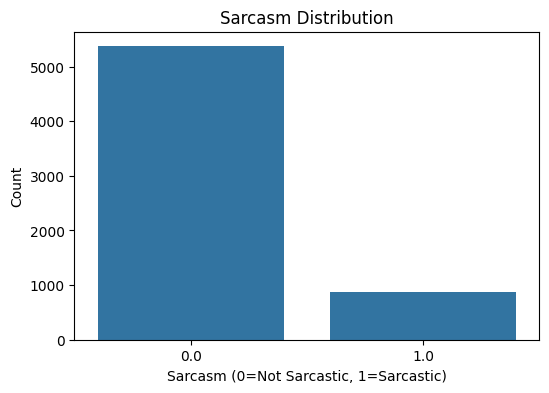

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sarcasm')
plt.title("Sarcasm Distribution")
plt.xlabel("Sarcasm (0=Not Sarcastic, 1=Sarcastic)")
plt.ylabel("Count")
plt.show()

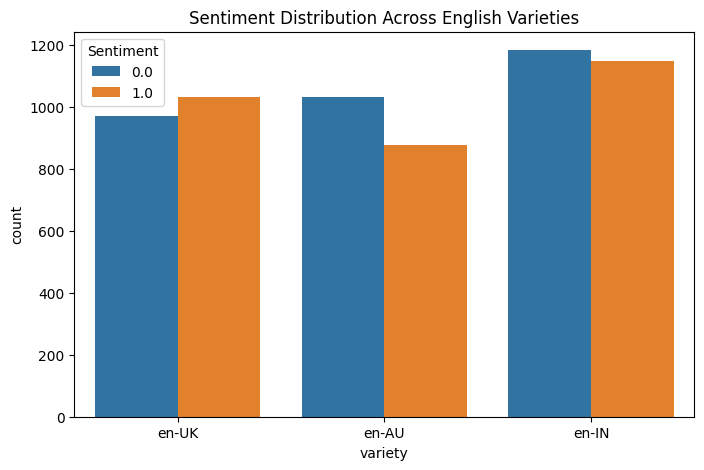

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='variety', hue='Sentiment')
plt.title("Sentiment Distribution Across English Varieties")
plt.show()

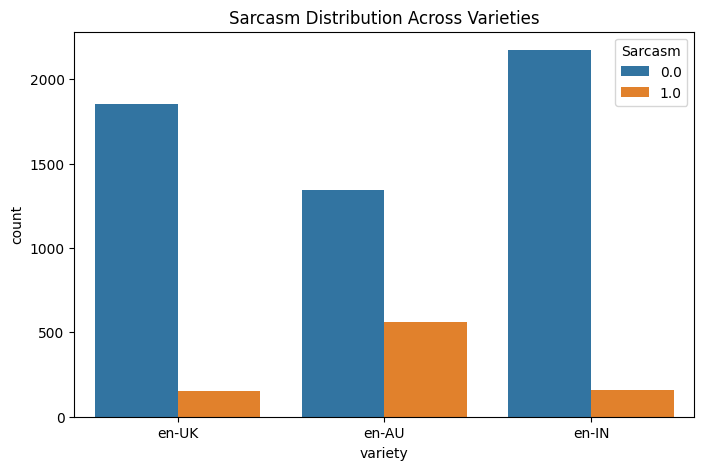

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='variety', hue='Sarcasm')
plt.title("Sarcasm Distribution Across Varieties")
plt.show()

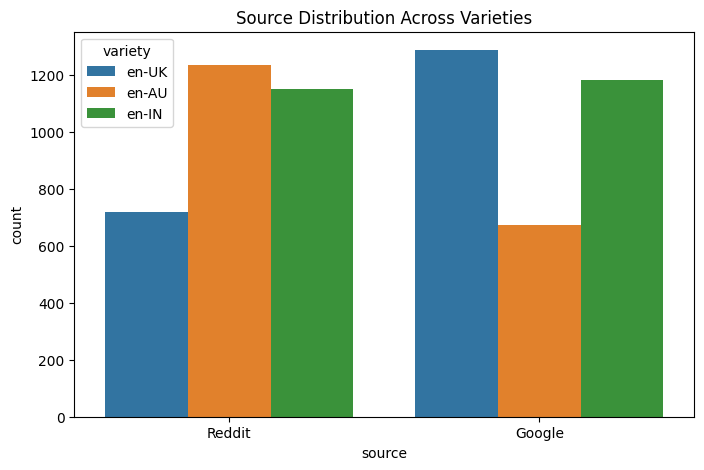

In [9]:
#Domain Split Visualisation (Reddit vs Google)

#The dataset contains two domains.
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="source",hue="variety")
plt.title("Source Distribution Across Varieties")
plt.show()

In [10]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

sample_text = df['text'].iloc[0]

tokens = word_tokenize(sample_text)

print("Sample text:", sample_text)
print("Tokens:", tokens)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Sample text: I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.
Tokens: ['I', "'m", 'a', 'member', 'of', 'the', 'Green', 'Party', 'but', 'I', "'ll", 'be', 'voting', 'Lib', 'Dem', 'as', 'it', "'s", 'so', 'tight', 'here', 'between', 'Lib', 'Dem', 'and', 'Tory', '.', 'I', 'can', 'not', 'contemplate', 'our', 'useless', 'tit', 'of', 'a', 'Tory', 'MP', 'being', 'reelected', '.', 'I', "'ll", 'use', 'the', 'Swap', 'My', 'Vote', 'website', 'so', 'someone', 'somewhere', 'can', 'vote', 'Green', 'for', 'me', '.']


In [11]:
from collections import Counter
import re

def get_vocab(text_series):

    words = []

    for text in text_series:
        tokens = re.findall(r'\b\w+\b', text.lower())
        words.extend(tokens)

    return set(words)

uk_vocab = get_vocab(df[df['variety']=='en-UK']['text'])
in_vocab = get_vocab(df[df['variety']=='en-IN']['text'])

print("UK vocab size:", len(uk_vocab))
print("IN vocab size:", len(in_vocab))

UK vocab size: 9777
IN vocab size: 9603


In [12]:
intersection = uk_vocab.intersection(in_vocab)
union = uk_vocab.union(in_vocab)

jaccard_similarity = len(intersection) / len(union)

print("Jaccard Similarity:", jaccard_similarity)

Jaccard Similarity: 0.3056659704911406


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

uk_text = " ".join(df[df['variety']=='en-UK']['text'])
in_text = " ".join(df[df['variety']=='en-IN']['text'])

vectorizer = TfidfVectorizer(max_features=5000)

tfidf = vectorizer.fit_transform([uk_text, in_text])

similarity = cosine_similarity(tfidf[0], tfidf[1])

print("Cosine Similarity:", similarity[0][0])

Cosine Similarity: 0.9522511952689596


In [14]:
vectorizer=TfidfVectorizer(ngram_range=(2,2),max_features=5000)

tfidf=vectorizer.fit_transform([uk_text,in_text])

similarity=cosine_similarity(tfidf[0],tfidf[1])

print("Bigram cosine similarity:",similarity[0][0])

Bigram cosine similarity: 0.786257038442026


POS Tag Distribution


In [15]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [16]:
import spacy
nlp=spacy.load("en_core_web_sm")

In [17]:
from collections import Counter

def pos_distribution(texts):

    pos_counts=Counter()

    for text in texts[:2000]:
        doc=nlp(text)
        pos_counts.update([token.pos_ for token in doc])

    return pos_counts

In [18]:
uk_pos=pos_distribution(df[df['variety']=="en-UK"]["text"])
in_pos=pos_distribution(df[df['variety']=="en-IN"]["text"])

print(uk_pos)
print(in_pos)

Counter({'NOUN': 24626, 'VERB': 14481, 'PUNCT': 13910, 'ADJ': 12730, 'PRON': 12141, 'DET': 11578, 'ADP': 11290, 'AUX': 9918, 'ADV': 8759, 'CCONJ': 5437, 'PART': 3808, 'PROPN': 3653, 'SCONJ': 2505, 'NUM': 1312, 'SPACE': 545, 'INTJ': 251, 'SYM': 115, 'X': 93})
Counter({'NOUN': 15908, 'PUNCT': 8488, 'VERB': 7999, 'ADJ': 7614, 'PRON': 6475, 'ADP': 6366, 'AUX': 5851, 'DET': 5451, 'PROPN': 5286, 'ADV': 4545, 'CCONJ': 3127, 'PART': 2060, 'SCONJ': 1342, 'NUM': 922, 'SPACE': 444, 'INTJ': 209, 'X': 151, 'SYM': 101})


In [19]:
import nltk
from nltk.tokenize import word_tokenize

def preprocess(text):
    return [word.lower() for word in word_tokenize(text)]

def type_token_ratio(texts):

    tokens=[]

    for text in texts:
        tokens.extend(preprocess(text))

    return len(set(tokens))/len(tokens)

In [20]:
!pip install textstat
import textstat

uk_sample=" ".join(df[df['variety']=="en-UK"]["text"].sample(200))
in_sample=" ".join(df[df['variety']=="en-IN"]["text"].sample(200))

print("UK readability:",textstat.flesch_reading_ease(uk_sample))
print("IN readability:",textstat.flesch_reading_ease(in_sample))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.2 MB/s eta 0:00:00
UK readability: 71.69150275671566
IN readability: 70.17921753041175


In [21]:
uk_ttr=type_token_ratio(df[df['variety']=="en-UK"]["text"])
in_ttr=type_token_ratio(df[df['variety']=="en-IN"]["text"])

print("UK TTR:",uk_ttr)
print("IN TTR:",in_ttr)

UK TTR: 0.07416559127170343
IN TTR: 0.10553037752789773


In [45]:
df['length'] = df['text'].apply(lambda x: len(x.split()))

df.groupby('variety')['length'].mean()

,length
variety,
en-AU,57.381751
en-IN,35.627358
en-UK,60.602794


In [24]:
from collections import Counter

words = " ".join(df[df['variety']=="en-AU"]["text"]).split()

Counter(words).most_common(10)

[('the', 4786),
 ('and', 3161),
 ('to', 2843),
 ('a', 2704),
 ('of', 1979),
 ('in', 1414),
 ('was', 1390),
 ('is', 1373),
 ('I', 1365),
 ('for', 1246)]

Saving all the output tables


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

def save_table(df, title, filename):

    fig, ax = plt.subplots(figsize=(6,2))
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    plt.title(title)
    plt.savefig(filename, bbox_inches='tight')
    plt.close()

In [30]:
jaccard_df = pd.DataFrame({
    "Comparison": ["en-UK vs en-IN"],
    "Jaccard Similarity": [jaccard_similarity]
})

save_table(jaccard_df, "Jaccard Similarity", "jaccard_table.png")

In [34]:
sentiment_counts = df['Sentiment'].value_counts().reset_index()
sentiment_counts.columns = ["Sentiment", "Count"]

save_table(sentiment_counts, "Sentiment Distribution", "sentiment_table.png")

In [36]:
sarcasm_counts = df['Sarcasm'].value_counts().reset_index()
sarcasm_counts.columns = ["Sarcasm", "Count"]

save_table(sarcasm_counts, "Sarcasm Distribution", "sarcasm_table.png")

In [38]:
sent_variety = pd.crosstab(df['variety'], df['Sentiment']).reset_index()

save_table(sent_variety, "Sentiment per Variety", "sentiment_variety_table.png")

In [40]:
sar_variety = pd.crosstab(df['variety'], df['Sarcasm']).reset_index()

save_table(sar_variety, "Sarcasm per Variety", "sarcasm_variety_table.png")

In [41]:
domain_table = pd.crosstab(df['variety'], df['source']).reset_index()

save_table(domain_table, "Domain Distribution", "domain_table.png")

In [43]:
summary_df = pd.DataFrame({
    "Metric": ["Jaccard", "TF-IDF (Unigram)", "TF-IDF (Bigram)"],
    "Value": [jaccard_similarity, unigram_similarity, bigram_similarity]
})

save_table(summary_df, "Vocabulary Similarity Summary", "summary_table.png")